Darío Paco Guisado.

## Ejercicio 1: PAS.

Un PAS (Paseo Aleatorio Simple) de parámetro p es un proceso estocástico indexado en los naturales.

En tiempo 0, la posición inicial $X_0 = 0$ con probabilidad 1.

Se genera una familia de pasos $Z_t$, con $t$ un natural. $Z_t$ toma los valores 1 con probabilidad p, y -1 con probabilidad 1-p. Las variables $Z_t$ son mutuamente independientes y actúan como pasos del Paseo Aleatorio Simple.

En cada instante de tiempo, se tendrá que la posición se calculará como la posición anterior más el paso que se da en instante t. $X_{t} = X_{t-1} + Z_{t}$.

El PAS entonces modela la posición de un objeto que empieza en posición 0 y se da hacia adelante o hacia atrás por unidad de tiempo, de manera independiente a su movimiento anterior. En este caso, p mide la probabilidad de que se mueva hacia adelante.


Vamos a empezar a implementar el PAS. Como el PAS es infinito, tomaremos un corte de tiempo (al que llamaremos n o Pasos) para simularlo. También llamaremos reps al número de simulaciones que hagamos.

Importamos librerías. Definimos primero la función PAS.

In [58]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


#Esta función me devuelve el Paso Aleatorio.
def simular_PAS(p, n, reps):
  # reps: cantidad de PAS que estoy simulando.
  # n: El número de pasos del PAS.
  # p: La probabilidad de que el siguiente paso de un PAS sea hacia arriba.
  # Output= pas : El PAS, en forma de array de forma (reps, n+1), empezando por el paso 0.

  #Compruebo que la probabilidad es correcta.
  if p > 1 or p < 0:
    raise ValueError("La probabilidad ha de estar entre 0 y 1")
  #Compruebo que los pasos son correctos.
  if n < 0:
    raise ValueError("Debe haber al menos un paso.")
  #Compruebo que las repeticiones son correctas.
  if reps < 1:
    raise ValueError("Debe haber al menos una simulación.")

  #Este proceso genera el PAS. Primero, genera números aleatorios uniformemente en (0, 1).
  pas = np.random.rand(reps,n+1)
   #Considero un paso hacia arriba si el número aleatorio es menor que p, con probablidad p.
  pas = 2*(pas < p) -1
  # Para general el PAS, el paso 0 es siempre 0, y los demás se obtienen sumando por filas, acumuladamente, los pasos.
  pas[:,0] = 0
  pas = np.cumsum(pas,axis=1)

  return pas



El resultado de la función, pas, es una simulación de reps PAS.
Tiene forma de array con reps filas y n+1 columnas.
Cada fila muestra una simulación particular, y cada columna muestra el estado de todas las simulaciones en un tiempo fijo.

Aplicamos el programa.

[[ 0  1  2 ... 68 67 68]
 [ 0  1  2 ... 66 67 66]
 [ 0  1  0 ... 54 53 52]
 ...
 [ 0 -1 -2 ... 80 81 82]
 [ 0  1  2 ... 58 57 58]
 [ 0  1  0 ... 86 85 86]]


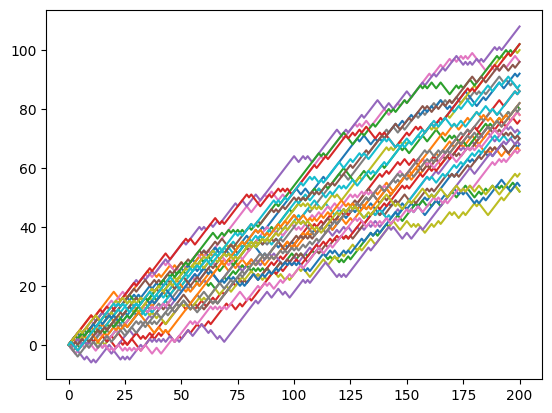

In [59]:

#Aquí hacemos el PAS. Cambia la cantidad (reps), los pasos (n), y la probabilidad (p) como desees.
#IfMedia aporta si quieres la recta de media del PAS. IfVarianza aporta lo mismo, pero para la desviación.

reps=30
n=200
p=0.7

#Utilizamos nuestra función simular_pas. El print sirve para que puedas ver que funciona.
pas = simular_PAS(p, n, reps)
print(pas)

#Hacemos un array de la forma [0,1 \ldots... Pasos+1]
x = np.linspace(0, n, n+1)


#Hacemos un plot. Para todas las reps, pintamos.
plt.figure()
for i in range(reps):
  plt.plot(x, pas[i,], '-')

plt.savefig('pas1.png')
plt.show()



Podemos hacer gráficas con media y varianza. Lo siguiente servirá de test para
la función con gráfica.

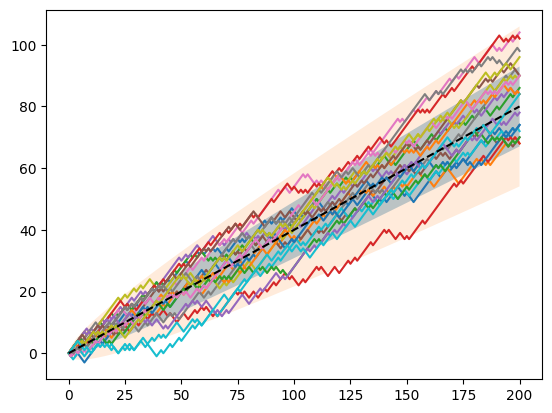

In [60]:
#Aquí hacemos el PAS. Cambia la cantidad (reps), los pasos (n), y la probabilidad (p) como desees.
#IfMedia aporta si quieres la recta de media del PAS. IfVarianza aporta lo mismo, pero para la desviación.

reps=30
n=200
p=0.7
IfMedia = True
IfVarianza = True

pas = simular_PAS(p, n, reps)


x = np.linspace(0, n, n+1)
media = (2*p-1)*x
sdev = (4*x*p*(1-p))**0.5
#Con Líneas discontinuas marca la media, en color negro.
plt.figure()
for i in range(Reps):
  plt.plot(x, pas[i,], '-')
#El IfMedia indica si quieres que aparezca la media marcada.
if IfMedia:
  plt.plot(x, media, 'k--')
#El IfVarianza indica si quieres que aparezca la varianza marcada. En este paso, no se añade de forma "limpia".
if IfVarianza:
  #fill_between rellena el espacio entre 2 funciones, para alpha la transparencia (0 es transparente, 1 es opaco.)
    plt.fill_between(x, media - sdev, media + sdev, alpha=0.35, label="±1σ")
    plt.fill_between(x, media - 2*sdev, media + 2*sdev, alpha=0.15, label = "±2σ")
plt.savefig('pas1.pdf')
plt.show()

Hago una función que me permita representar un PAS como gráfica.

Primero, aplica el mismo proceso que la función simular_PAS. Devuelve por pantalla y guardado en formato pdf una gráfica de las simulaciones, así como el PAS.
Puedes en esta versión también imprimir directamente el PAS (sin tener que hacer un print, default: false) y poner una semilla para que los resultados sean replicables (Semilla $0$ implica Random. Semilla $\neq 0$ implica semilla fija).

In [61]:
def simular_PAS_Grafica (Nombre, p, n, reps, IfMedia=False, IfVarianza=False, Semilla=0, Lista = False):
  #reps: Número de repeticiones que deseas de un PAS
  #n: Número de pasos que deseas de un PAS
  #p: Probabilidad de un paso para arriba.
  #IfMedia: ¿Quieres hacer aparecer la recta de la media en el programa? Default: No.
  #IfVarianza: ¿Quieres hacer aparecer las curvas de varianza en el programa? Default: No.
  #Semilla: Indica la semilla que quieras usar, si la semilla > 0. Default: 0 (aleatoria).
  #Nombre es el nombre con el que guardará el archivo.
  #Lista muestra si quieres mostrar el PAS.
  #output: Un PAS y su gráfica.
  if Semilla != 0:
      np.random.seed(Semilla)

  #Compruebo que la probabilidad es correcta.
  if p > 1 or p < 0:
    raise ValueError("La probabilidad ha de estar entre 0 y 1")
  #Compruebo que los pasos son correctos.
  if n < 0:
    raise ValueError("Debe haber al menos un paso.")
  #Compruebo que las repeticiones son correctas.
  if reps < 1:
    raise ValueError("Debe haber al menos una simulación.")
  #Una vez lo he comprobado, genero el PAS.


  #Este proceso genera el PAS. Primero, genera números aleatorios uniformemente en (0, 1).
  pas = np.random.rand(reps,n+1)
   #Considero un paso hacia arriba si el número aleatorio es menor que p, con probablidad p.
  pas = 2*(pas < p) -1
  # Para general el PAS, el paso 0 es siempre 0, y los demás se obtienen sumando por filas, acumuladamente, los pasos.
  pas[:,0] = 0
  pas = np.cumsum(pas,axis=1)

  #Si quieres mostrar el PAS, se activa un print. Puede ser útil para comprobar.
  if Lista:
    print(pas)
  #Ahora voy a imprimir la gráfica.

  x = np.linspace(0, n, n+1)
  #Calculo la media y la desviación típica.
  media = (2*p-1)*x
  sdev = (4*x*p*(1-p))**0.5

  plt.figure()
  for i in range(reps):
    plt.plot(x, pas[i,], '-')
  #El IfMedia indica si quieres que aparezca la media marcada.
   #Con Líneas discontinuas marca la media, en color negro.
  if IfMedia:
    plt.plot(x, media, 'k--', label = "Media")
  if IfVarianza:
  #El IfVarianza indica si quieres que aparezca los rangos de desviación típica marcada.
    plt.fill_between(x, media - sdev, media + sdev, alpha=0.35, label="±1σ")
    plt.fill_between(x, media - 2*sdev, media + 2*sdev, alpha=0.15, label = "±2σ")
  plt.savefig(str(Nombre) +'.pdf')
  #Si hay alguna leyenda que mostrar, ya que aparecen tanto en la media como en la varianza.
  if IfMedia or IfVarianza:
    plt.legend(loc="upper left")
  plt.show()
#Devuelvo el PAS.
  return pas

Podemos empezar a hacer las figuras pedidas. La última requiere un tratamiento especial y se explica en el código.

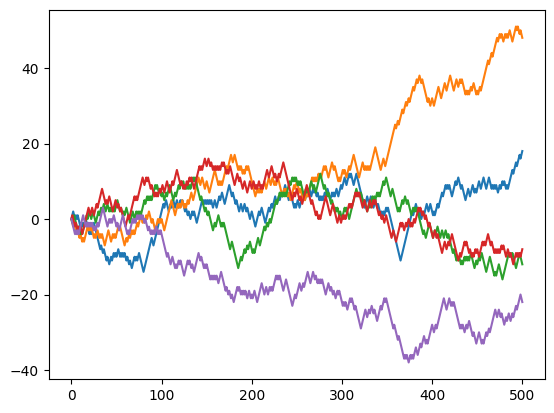

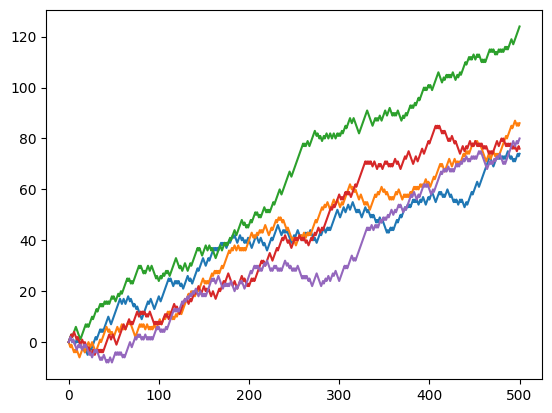

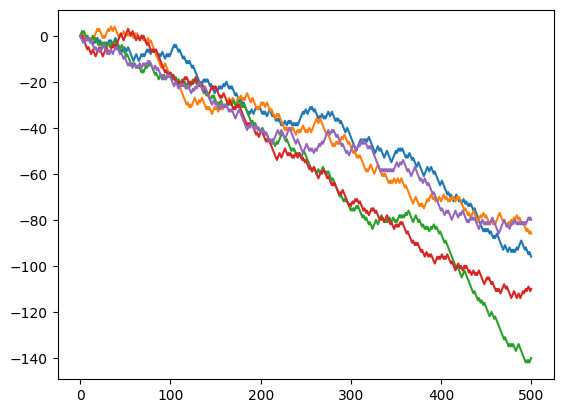

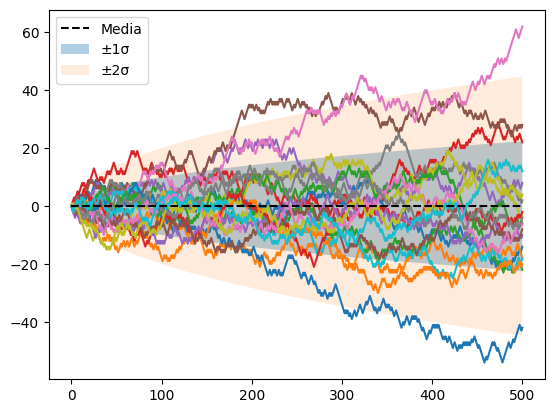

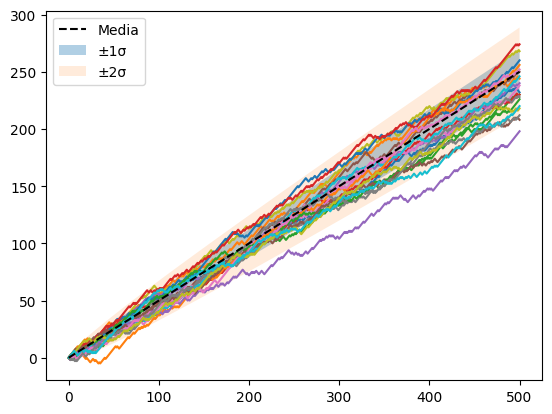

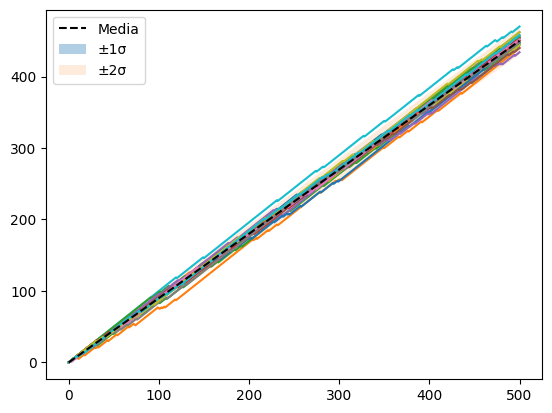

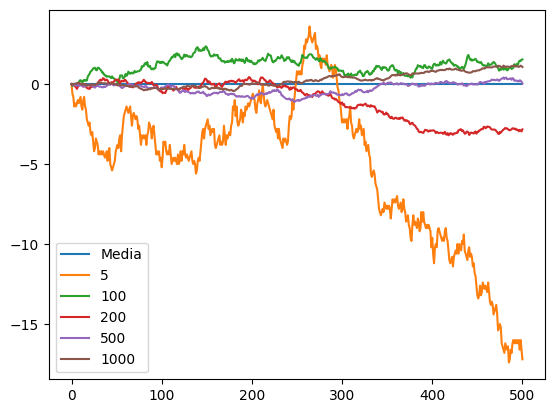

In [62]:
#La primera gráfica, aparece en la diapositiva 16 del Tema 1. (reps = 5, n = 500, p = 0.5)
simular_PAS_Grafica('Graf1', 0.5, 500, 5)
#La segunda gráfica, aparece en la diapositiva 17 del Tema 1. (reps = 5, n = 500, p = 0.6)
simular_PAS_Grafica('Graf2', 0.6, 500, 5)
#La tercera gráfica, aparece en la diapositiva 18 del tema 1. (reps = 5, n = 500, p = 0.4)
simular_PAS_Grafica('Graf3', 0.4, 500, 5)

#La cuarta gráfica, aparece en la diapositiva 30 del Tema 1. (reps = 20, n = 500, p = 0.5)
simular_PAS_Grafica('Graf4', 0.5, 500, 20, True, True)
#La quinta gráfica, aparece en la diapositiva 31 del Tema 1. (reps = 20, n = 500, p = 0.75)
simular_PAS_Grafica('Graf5', 0.75, 500, 20, True, True)
#La sexta gráfica, aparece en la diapositiva 32 del tema 1. (reps = 20, n = 500, p = 0.95)
simular_PAS_Grafica('Graf6', 0.95, 500, 20, True, True)


#La última gráfica, aparece en la diapositiva 35 del Tema 1. Utiliza medias, así que la haremos por separado.
#Calculo con la función simular_PAS (sin gráfica) las trayectorias a promediar.

#np.sum con axis 0 me da la suma por columnas, es decir, suma todas las trayectorias en el paso n.
#Divido entre el número de reps para obtener la media empírica en cada caso.
pas5 = np.sum(simular_PAS(0.5,500,5),axis=0)/5
pas100 = np.sum(simular_PAS(0.5,500,100), axis = 0)/100
pas200 = np.sum(simular_PAS(0.5,500,200),axis=0)/200
pas500 = np.sum(simular_PAS(0.5,500,500), axis = 0)/500
pas1000 = np.sum(simular_PAS(0.5,500,1000), axis = 0)/1000

#Ahora las grafico.
x = np.linspace(0,500,501)
plt.figure()
#La media, al ser p = 0.5, es siempre 0.
plt.plot(x, np.zeros(501), label= "Media")
#Ahora hago plot de los arrays que son medias.
plt.plot(x, pas5, label = "5")
plt.plot(x, pas100, label = "100")
plt.plot(x, pas200, label = "200")
plt.plot(x, pas500, label = "500")
plt.plot(x, pas1000, label = "1000")
#Pongo la leyenda.
plt.legend(loc="lower left")
plt.savefig('Graf7.png')
plt.show()

